House price predictor

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

import warnings
warnings.filterwarnings('ignore')

In [58]:
data=pd.read_csv("Housing.csv")
df=pd.DataFrame(data)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [59]:
df=df.dropna()
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


Label encoding

In [60]:
encoder=LabelEncoder()
df['mainroad']=encoder.fit_transform(df['mainroad'])
df['guestroom']=encoder.fit_transform(df['guestroom'])
df['basement']=encoder.fit_transform(df['basement'])
df['hotwaterheating']=encoder.fit_transform(df['hotwaterheating'])
df['airconditioning']=encoder.fit_transform(df['airconditioning'])
df['prefarea']=encoder.fit_transform(df['prefarea'])
df


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,unfurnished
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished


One-hot encoding

In [61]:
df = pd.get_dummies(df, columns=['furnishingstatus'])
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,False,False,True
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,False,True,False
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,False,False,True
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,True,False,False


Data cleaning

In [62]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_furnished       545 non-null    b

price                              0
area                               0
bedrooms                           0
bathrooms                          0
stories                            0
mainroad                           0
guestroom                          0
basement                           0
hotwaterheating                    0
airconditioning                    0
parking                            0
prefarea                           0
furnishingstatus_furnished         0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64

Correlation Heatmap

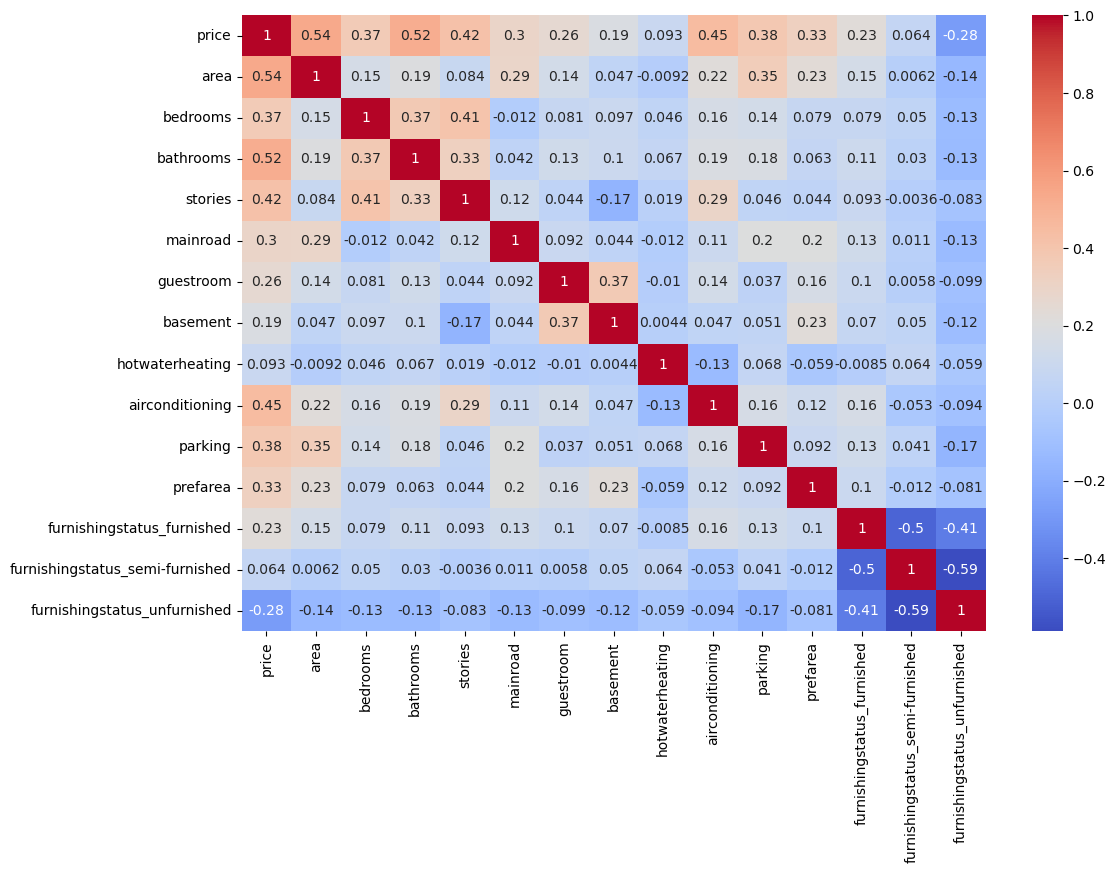

In [63]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

spliting X and y

In [64]:
X=df.drop(['price'],axis=1)
y=df['price']


Train and test spliting

In [65]:
XTrain,XTest,yTrain,yTest=train_test_split(X,y,test_size=0.3,random_state=42)

Random Forest Regressor

In [66]:
model=RandomForestRegressor(random_state=42,n_estimators=100)
model.fit(XTrain,yTrain)
prediction=model.predict(XTest)

Evalution of model

In [67]:
print(f"MAE: {mean_absolute_error(yTest,prediction)}")
print(f"MSE: {mean_squared_error(yTest,prediction)}")
print(f"RMSE: {np.sqrt(mean_squared_error(yTest,prediction))}")
print(f"R2: {r2_score(yTest,prediction)}")

MAE: 954748.0705284553
MSE: 1837544327559.8486
RMSE: 1355560.5215407568
R2: 0.5732983286692714


Visualization

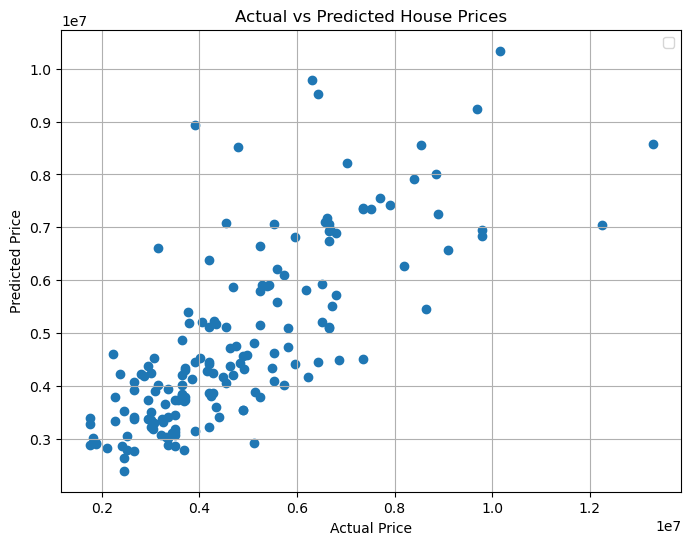

In [68]:
plt.figure(figsize=(8,6))
plt.scatter(yTest,prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.legend()
plt.show()     

Inputs

In [ ]:
try:
    area = int(input("Enter area: "))
    bedrooms = int(input("Enter number of bedrooms: "))
    bathrooms = int(input("Enter number of bathrooms: "))
    stories = int(input("Enter number of stories: "))

    mainroad = input("Main road access (yes/no): ").lower()
    guestroom = input("Guest room (yes/no): ").lower()
    basement = input("Basement (yes/no): ").lower()
    hotwaterheating = input("Hot water heating (yes/no): ").lower()
    airconditioning = input("Air conditioning (yes/no): ").lower()

    parking = int(input("Enter parking spaces: "))

    prefarea = input("Preferred area (yes/no): ").lower()

    furnishingstatus=input("Furnishing status? (furnished/semi-furnished/unfurnished)")

    userInput=pd.DataFrame([{
        'area': area,
        'bedrooms': bedrooms,
        'bathrooms': bathrooms,
        'stories': stories,
        'mainroad': mainroad,
        'guestroom':guestroom,
        'basement': basement,
        'hotwaterheating':hotwaterheating,
        'airconditioning': airconditioning,
        'parking': parking,
        'prefarea': prefarea,
        'furnishingstatus_furnished':1 if furnishingstatus=="furnished" else 0,
        'furnishingstatus_semi-furnished': 1 if furnishingstatus=="semi-furnished" else 0,
        'furnishingstatus_unfurnished': 1 if furnishingstatus=="unfurnished" else 0
        
    }])

    userInput['mainroad']=encoder.fit_transform(userInput['mainroad'])
    userInput['guestroom']=encoder.fit_transform(userInput['guestroom'])
    userInput['basement']=encoder.fit_transform(userInput['basement'])
    userInput['hotwaterheating']=encoder.fit_transform(userInput['hotwaterheating'])
    userInput['airconditioning']=encoder.fit_transform(userInput['airconditioning'])
    userInput['prefarea']=encoder.fit_transform(userInput['prefarea'])

    predictedPrice=model.predict(userInput)

    print("The house price may be",predictedPrice)
except:
    print("An error occured")


The house price may be [10673950.]
